<center>
    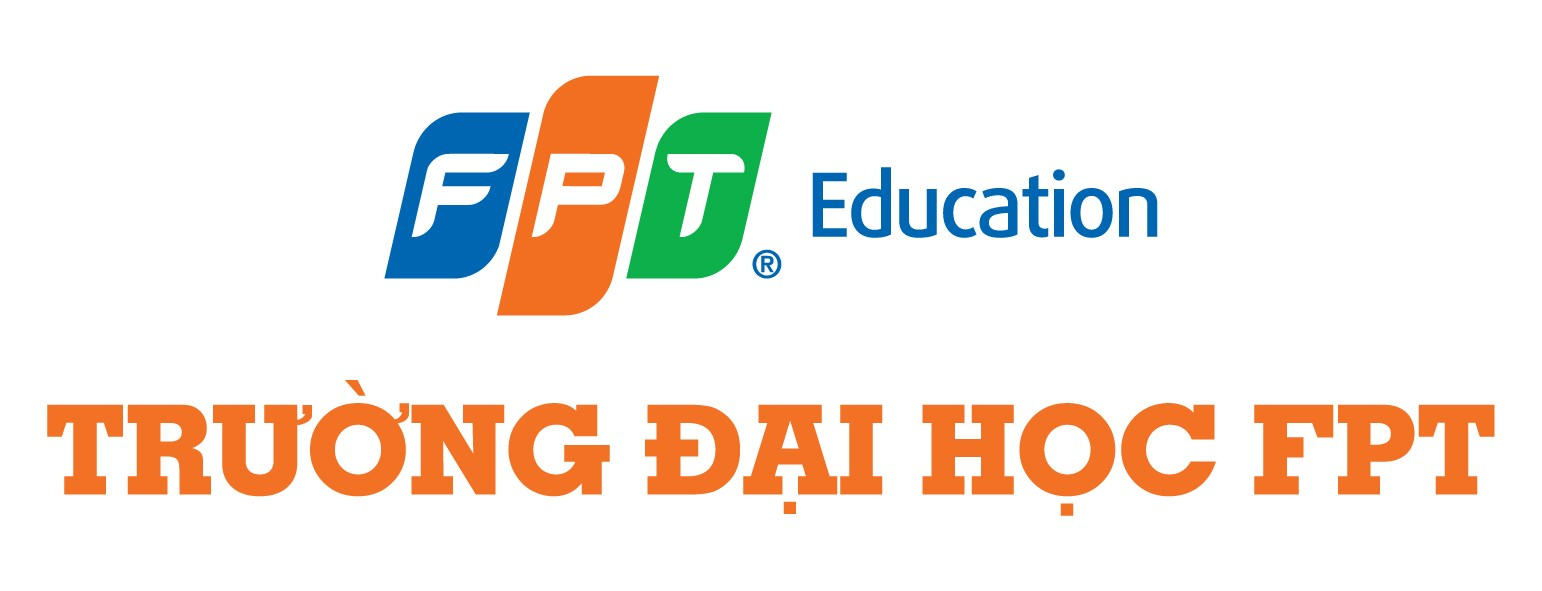
    
# Reinforcement Learning 
# Lab 2: Taxi-v3 using TD(0) 
</center>



<br>

#### Class name: AI1902-AA______________________

#### Student code: HE195216____________________

#### Student name: Dương Ngọc Anh___________________

<br>

<a alt='AI1902'></a>
## Objectives

You will build and train an agent for the Taxi-v3 environment (Gymnasium) using Temporal-Difference learning TD(0). Your solution must:

1. implement TD(0) policy evaluation to estimate a value function, and

2. use the learned value estimates to improve the policy and obtain a strong control agent.

You are not allowed to use built-in RL libraries that directly implement TD/SARSA/Q-learning (e.g., Stable-Baselines, RLlib trainers, etc.). You must implement the learning logic yourself.

After completing this assignment you will be able to:

*   Describe the concept of reinforcement learning include agent, environment, action, reward ...
*   Understand about one of the RL optimization methods
*   Implement one of the reinforcement learing algorithms

Estimated time needed: **90** minutes
<h3 style='color:red;'>Note: After submitting the assignment, students will have to answer oral questions to demonstrate their understanding of the implemented algorithm.
</h5>

## 1. Introduction

<center><img src='img/taxi.gif' width = 300/></center>

The Taxi environment is part of the Toy Text environments which contains general information about the environment.
| &nbsp; | &nbsp; |
| :--- | :--- |
|Action Space|`Discrete(6)`|
|Observation Space|`Discrete(500)`|
|import|`gymnasium.make("Taxi-v3")`|


The problem involves navigating to passengers in a grid world, picking them up and dropping them off at one of four locations.

### Description
There are four designated pick-up and drop-off locations (Red, Green, Yellow and Blue) in the 5x5 grid world. The taxi starts off at a random square and the passenger at one of the designated locations.

The goal is move the taxi to the passenger’s location, pick up the passenger, move to the passenger’s desired destination, and drop off the passenger. Once the passenger is dropped off, the episode ends.

The player receives positive rewards for successfully dropping-off the passenger at the correct location. Negative rewards for incorrect attempts to pick-up/drop-off passenger and for each step where another reward is not received.

Map:

     1  2  3  4  5
    +--------------+
    |R :::|:::::: G|  1
    |:::::|::::::::|  2
    |::::::::::::::|  3 
    |::|:::::|:::::|  4
    |Y |:::::|B :::|  5
    +--------------+


### Action Space
The action shape is `(1,)` in the range `{0, 5}` indicating which direction to move the taxi or to pickup/drop off passengers.

- 0: Move south (down)
- 1: Move north (up)
- 2: Move east (right)
- 3: Move west (left)
- 4: Pickup passenger
- 5: Drop off passenger

### Observation Space
There are 500 discrete states since there are 25 taxi positions, 5 possible locations of the passenger (including the case when the passenger is in the taxi), and 4 destination locations.

Destination on the map are represented with the first letter of the color.

Passenger locations:
- 0: Red
- 1: Green
- 2: Yellow
- 3: Blue
- 4: In taxi

Destinations:
- 0: Red
- 1: Green
- 2: Yellow
- 3: Blue

An observation is returned as an int() that encodes the corresponding state, calculated by ((taxi_row * 5 + taxi_col) * 5 + passenger_location) * 4 + destination

Note that there are 400 states that can actually be reached during an episode. The missing states correspond to situations in which the passenger is at the same location as their destination, as this typically signals the end of an episode. Four additional states can be observed right after a successful episodes, when both the passenger and the taxi are at the destination. This gives a total of 404 reachable discrete states.

### Starting State
The initial state is sampled uniformly from the possible states where the passenger is neither at their destination nor inside the taxi. There are 300 possible initial states: 25 taxi positions, 4 passenger locations (excluding inside the taxi) and 3 destinations (excluding the passenger’s current location).

### Reward
- -1 per step unless other reward is triggered.
- +20 delivering passenger.

- -10 executing “pickup” and “drop-off” actions illegally.

An action that results a noop, like moving into a wall, will incur the time step penalty. Noops can be avoided by sampling the `action_mask` returned in `info`.

### Episode End
The episode ends if the following happens:

- Termination: 1. The taxi drops off the passenger.
- Truncation (when using the time_limit wrapper): 1. The length of the episode is 200.

### Information
`step()` and `reset()` return a dict with the following keys:

- p - transition probability for the state.
- action_mask - if actions will cause a transition to a new state.

For some cases, taking an action will have no effect on the state of the episode. In v0.25.0, info["action_mask"] contains a np.ndarray for each of the actions specifying if the action will change the state.

To sample a modifying action, use action = env.action_space.sample(info["action_mask"]) Or with a Q-value based algorithm action = np.argmax(q_values[obs, np.where(info["action_mask"] == 1)[0]]).

### Arguments
```python
import gymnasium as gym
gym.make('Taxi-v3')
```

`is_raining=False`: If True the cab will move in intended direction with probability of 80% else will move in either left or right of target direction with equal probability of 10% in both directions.

`fickle_passenger=False`: If true the passenger has a 30% chance of changing destinations when the cab has moved one square away from the passenger’s source location. Passenger fickleness only happens on the first pickup and successful movement. If the passenger is dropped off at the source location and picked up again, it is not triggered again.

### References
[1] T. G. Dietterich, “Hierarchical Reinforcement Learning with the MAXQ Value Function Decomposition,” Journal of Artificial Intelligence Research, vol. 13, pp. 227–303, Nov. 2000, doi: 10.1613/jair.639.


In [1]:
#!pip install gym
#!pip install gymnasium[toy_text]

random_seed = 42 # for the random task, using this seed to generate

## Task 1 — Setup & Baseline (15%)

1. Install and import Gymnasium.
2. Create the environment Taxi-v3.
3. Run N=100 episodes with a random policy.

Report:
- average return,
- average episode length,
- fraction of episodes with successful dropoff.

In [2]:
# YOUR CODE HERE

import gymnasium as gym
import numpy as np
import random
import matplotlib.pyplot as plt

env = gym.make('Taxi-v3', render_mode='ansi')
env.reset(seed=random_seed)
# Get the number of actions and states from the environment
N = 100
total_returns = []
episode_lengths = []
successful_dropoffs = 0

for episode in range(N):
  state,info = env.reset()
  episode_return = 0
  done = False
  steps = 0

  while not done:
    action = env.action_space.sample() # take a random action
    state, reward, terminated, truncated, info = env.step(action)
    episode_return += float(reward)
    steps += 1
    done = terminated or truncated

    if terminated and reward == 20:
      successful_dropoffs += 1

  total_returns.append(episode_return)
  episode_lengths.append(steps)


avg_return = np.mean(total_returns)
avg_length = np.mean(episode_lengths)
success_faction = successful_dropoffs / N

print(f"Average Return: {avg_return:.2f}")
print(f"Average Episode Length: {avg_length:.2f}")
print(f"Success Fraction: {success_faction:.2%}")

Average Return: -762.87
Average Episode Length: 196.92
Success Fraction: 2.00%


## Task 2 — TD(0) Policy Evaluation (30%)

Implement tabular TD(0) to estimate state-value $V_\pi(s)$ for a fixed policy $\pi$

**TD(0) update rule (state-value):**
Let transition $(s_t, a_t, r_{t+1}, s_{t+1}, done)$. Then:

- if done:
$$V(s_t) \leftarrow V(s_t) + \alpha(r - V(s_t)))$$

- else:
$$V(s_t) \leftarrow V(s_t) + \alpha(r + \gamma*V(s_{t+1}) - V(s_t))$$

Requirements:

1. Evaluate at least two different fixed policies, for example:
- random policy,
- a simple heuristic policy (you design it).

2. Plot (or tabulate) learning curves showing how average return changes as evaluation proceeds.

Deliverable: implementation of TD(0) evaluation + brief analysis.

Evaluating Random Policy using TD(0)...
Evaluating Heuristic Policy using TD(0)...


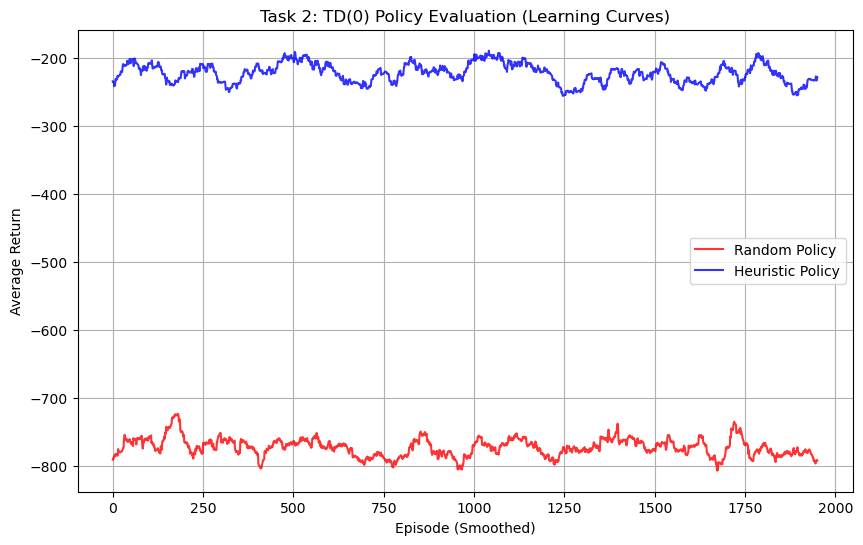

Random Policy Avg Return: -773.10
Heuristic Policy Avg Return: -222.26


In [3]:

# Policy A: Random Policy
def random_policy(state, env):
    return env.action_space.sample()

# Policy B: Simple Heuristic Policy
def heuristic_policy(state, env):
    # 10% chance of taking a random action to prevent getting stuck in walls
    if random.random() < 0.1:
        return env.action_space.sample()
        
    # Decode the state to get details: taxi position, passenger index, destination index
    taxi_row, taxi_col, pass_idx, dest_idx = env.unwrapped.decode(state)
    
    # Coordinates of locations: R(0), G(1), Y(2), B(3)
    locs = [(0, 0), (0, 4), (4, 0), (4, 3)]
    
    if pass_idx < 4:
        target_row, target_col = locs[pass_idx]
        if taxi_row == target_row and taxi_col == target_col:
            return 4  # Pickup action
    else:
        target_row, target_col = locs[dest_idx]
        if taxi_row == target_row and taxi_col == target_col:
            return 5  # Dropoff action
            
    # Simple navigation logic (move towards target)
    if taxi_row < target_row: return 0  
    if taxi_row > target_row: return 1  
    if taxi_col < target_col: return 2  
    if taxi_col > target_col: return 3 
        
    return env.action_space.sample()


# TD(0) Policy Evaluation Algorithm 

def td0_evaluation(env, policy_fn, num_episodes=2000, alpha=0.1, gamma=0.99):
    # Initialize the Value Table with zeros
    V = np.zeros(env.observation_space.n)
    episode_returns = []
    
    for ep in range(num_episodes):
        state, info = env.reset()
        done = False
        ep_return = 0.0
        
        while not done:
            action = policy_fn(state, env)
            next_state, reward, terminated, truncated, info = env.step(action)
            reward_f = float(reward)
            
            # TD(0) update rule
            if terminated:
                V[state] = V[state] + alpha * (reward_f - V[state])
            else:
                V[state] = V[state] + alpha * (reward_f + gamma * V[next_state] - V[state])
                
            ep_return += reward_f
            state = next_state
            done = terminated or truncated
            
        episode_returns.append(ep_return)
        
    return V, episode_returns


# Evaluate Policies & Plot Results

# Initialize environment
env = gym.make('Taxi-v3')
env.reset(seed=42)

print("Evaluating Random Policy using TD(0)...")
V_random, returns_random = td0_evaluation(env, random_policy, num_episodes=2000)

print("Evaluating Heuristic Policy using TD(0)...")
V_heuristic, returns_heuristic = td0_evaluation(env, heuristic_policy, num_episodes=2000)

def moving_average(data, window_size=50):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

# Plotting learning curves
plt.figure(figsize=(10, 6))
plt.plot(moving_average(returns_random), label='Random Policy', color='red', alpha=0.8)
plt.plot(moving_average(returns_heuristic), label='Heuristic Policy', color='blue', alpha=0.8)
plt.title("Task 2: TD(0) Policy Evaluation (Learning Curves)")
plt.xlabel("Episode (Smoothed)")
plt.ylabel("Average Return")
plt.legend()
plt.grid(True)
plt.show()

# Show statistics
print(f"Random Policy Avg Return: {np.mean(returns_random):.2f}")
print(f"Heuristic Policy Avg Return: {np.mean(returns_heuristic):.2f}")

- The heuristic policy should outperform the random policy, showing a higher average return.
- Because both policies are evaluated in a fixed state, their average returns remain flat, with noises from random start states
- Under random policy, the learned values are highly negative because of the step and illegal action penalties, while under the heuristic policy, the values are much higher because agent correctly navigates towards targets.

## Task 3 — Q-learning Control for Taxi-v3 (40%)

You will train a control agent for the Taxi-v3 environment using tabular Q-learning.

Q-learning is an off-policy Temporal-Difference control algorithm. Instead of estimating only the state-value function V(s), you will directly learn the action-value function Q(s, a), which represents the expected return of taking action a in state s and then following the best possible behavior afterward.

For a transition $(s_t, a_t, r_{t+1}, s_{t+1}, done)$, the Q-learning update rule is:

* if done:

$$
Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha [r - Q(s_t, a_t)]
$$

* else:

$$
Q(s_t, a_t) \leftarrow Q(s_t, a_t) + \alpha [r + \gamma \max_{a'} Q(s_{t+1}, a') - Q(s_t, a_t)]
$$

During training, use an $\epsilon$-greedy policy for action selection:

* With probability $\epsilon$ : choose a random action for exploration.
* With probability 1 - $\epsilon$ : choose the action with the highest Q-value.

Procedure:

1. Initialize the Q-table with zeros: Q(s, a) = 0 for all states and actions.
2. For each training episode:

   * Reset the environment and get the initial state.
   * Select actions using the $\epsilon$-greedy strategy.
   * Interact with the environment step by step.
   * Update Q(s, a) using the Q-learning update rule.
   * Stop when the episode terminates or reaches the maximum number of steps.
3. Optionally decay $\epsilon$ over time to reduce exploration and increase exploitation.
4. After training, evaluate the final policy using greedy action selection, where $\epsilon$ = 0.
5. Evaluate the trained agent over E = 500 episodes.

Requirements:

1. Implement tabular Q-learning yourself.
2. Do not use built-in reinforcement learning libraries such as Stable-Baselines, RLlib trainers, or other prebuilt Q-learning implementations.
3. Track training performance, such as average return per episode or average return over every N episodes.
4. Evaluate the final trained policy using:

   * average return,
   * success rate,
   * average episode length.

Deliverables:

* Implementation of the Q-learning algorithm.
* Final trained Q-table.
* Evaluation metrics: average return, success rate, and average episode length.
* A plot showing training performance over episodes.
* A brief analysis explaining how $\epsilon$, $\alpha$, and $\gamma$ affect the learning process.


Training agent using Q-learning...
Evaluating trained policy over 500 episodes...

=== Evaluation Metrics (Greedy Policy) ===
Average Return: 7.97
Success Rate: 100.00%
Average Episode Length: 13.03


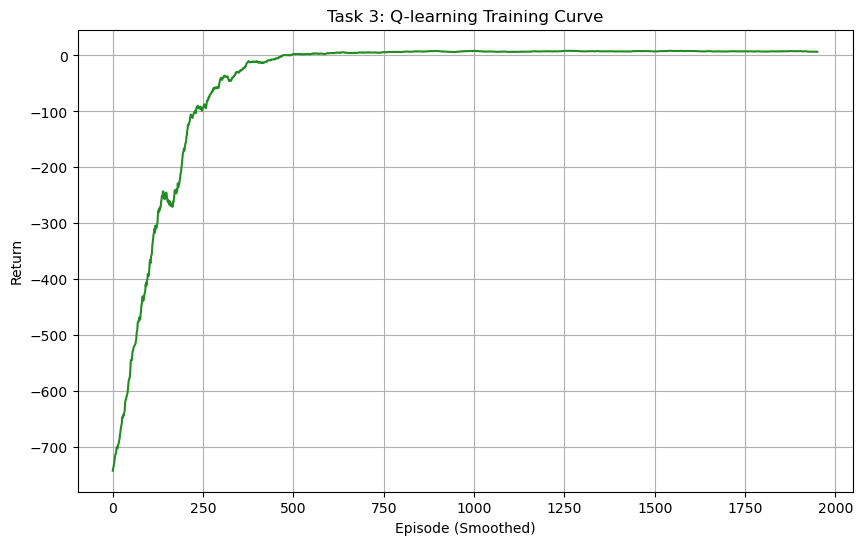

In [4]:
# YOUR CODE HERE

# Q-learning Algorithm Implementation

def q_learning(env, num_episodes=2000, alpha=0.3, gamma=0.99, epsilon=1.0, min_epsilon=0.01, decay_rate=0.005):
    # Initialize Q-table with zeros (500 states x 6 actions)
    Q = np.zeros((env.observation_space.n, env.action_space.n))
    episode_returns = []
    
    for episode in range(num_episodes):
        state, info = env.reset()
        done = False
        ep_return = 0.0
        
        while not done:
            # Epsilon-greedy action selection
            if random.random() < epsilon:
                action = env.action_space.sample()
            else:
                action = int(np.argmax(Q[state]))
                
            next_state, reward, terminated, truncated, info = env.step(action)
            reward_f = float(reward)
            
            # Q-learning Update Rule
            if terminated:
                # If done, no future states exist
                Q[state, action] = Q[state, action] + alpha * (reward_f - Q[state, action])
            else:
                # TD target uses the maximum Q-value of the next state (off-policy)
                best_next_action = np.argmax(Q[next_state])
                Q[state, action] = Q[state, action] + alpha * (reward_f + gamma * Q[next_state, best_next_action] - Q[state, action])
                
            ep_return += reward_f
            state = next_state
            done = terminated or truncated
            
        episode_returns.append(ep_return)
        
        # Exponential epsilon decay
        epsilon = max(min_epsilon, epsilon * np.exp(-decay_rate))
        
    return Q, episode_returns


# Evaluation Function

def evaluate_q_table(env, Q, num_episodes=500):
    total_returns = []
    episode_lengths = []
    successful_dropoffs = 0
    
    for _ in range(num_episodes):
        state, info = env.reset()
        done = False
        ep_return = 0.0
        steps = 0
        
        while not done:
            # Greedy action selection (epsilon = 0 for evaluation)
            action = int(np.argmax(Q[state]))
            state, reward, terminated, truncated, info = env.step(action)
            ep_return += float(reward)
            steps += 1
            done = terminated or truncated
            
            if terminated and reward == 20:
                successful_dropoffs += 1
                
        total_returns.append(ep_return)
        episode_lengths.append(steps)
        
    return np.mean(total_returns), (successful_dropoffs / num_episodes), np.mean(episode_lengths)


# Train, Evaluate, and Plot

env = gym.make('Taxi-v3')

# Set seed for reproducible results
random.seed(42)
np.random.seed(42)
env.reset(seed=42)

print("Training agent using Q-learning...")
Q, returns = q_learning(env, num_episodes=2000, alpha=0.3, gamma=0.99)

print("Evaluating trained policy over 500 episodes...")
avg_return, success_rate, avg_length = evaluate_q_table(env, Q, num_episodes=500)

# Print final evaluation metrics
print("\n=== Evaluation Metrics (Greedy Policy) ===")
print(f"Average Return: {avg_return:.2f}")
print(f"Success Rate: {success_rate:.2%}")
print(f"Average Episode Length: {avg_length:.2f}")

# Plot training learning curve
plt.figure(figsize=(10, 6))
# Using window=50 to smooth out training curve
smoothed_returns = np.convolve(returns, np.ones(50)/50, mode='valid')
plt.plot(smoothed_returns, color='forestgreen')
plt.title("Task 3: Q-learning Training Curve")
plt.xlabel("Episode (Smoothed)")
plt.ylabel("Return")
plt.grid(True)
plt.show()

- alpha (learning rate): dictates how much we update Q-value estimate based on new information. A rate too low slow down training, a rate too high might cause oscillations
- gamma (discount factor): dictates how much weight the agent places on future rewards vs immediate rewards. A high gamma is important to keep agent care about long term success
- epsilon (exploration): the probability of taking a random action. Epsilon = 1 guarantees early exploration of the entire grid world. Slowly decaying let the agent exploit its learned Q-table to maximize returns

## Task 4 — Hyperparameter Study (15%)

Run experiments varying at least two of:
- learning rate $\alpha$
- discount factor $\gamma$
- exploration $\epsilon$ (and optionally an $\epsilon$ decay schedule),
- number of episodes per policy-evaluation phase M.

Provide:
- a small table summarizing results,
- 3–5 sentences explaining your observed trends.

In [5]:
# YOUR CODE HERE

In [6]:
# Grid search experiments
alphas = [0.05, 0.1, 0.3]
gammas = [0.9, 0.99]

print("| Alpha (Learning Rate) | Gamma (Discount Factor) | Avg Return | Success Rate | Avg Episode Length |")
print("|-----------------------|-------------------------|------------|--------------|--------------------|")

for alpha in alphas:
    for gamma in gammas:
        # Re-train from scratch for each combination (1500 episodes)
        random.seed(42)
        np.random.seed(42)
        Q_test, _ = q_learning(env, num_episodes=1500, alpha=alpha, gamma=gamma)
        mean_ret, success_rate, mean_len = evaluate_q_table(env, Q_test, num_episodes=100)
        print(f"| {alpha} | {gamma} | {mean_ret:.2f} | {success_rate:.2%} | {mean_len:.2f} |")

| Alpha (Learning Rate) | Gamma (Discount Factor) | Avg Return | Success Rate | Avg Episode Length |
|-----------------------|-------------------------|------------|--------------|--------------------|
| 0.05 | 0.9 | -145.17 | 26.00% | 150.63 |
| 0.05 | 0.99 | -171.13 | 22.00% | 158.11 |
| 0.1 | 0.9 | -76.68 | 59.00% | 89.07 |
| 0.1 | 0.99 | -39.48 | 77.00% | 55.65 |
| 0.3 | 0.9 | 3.70 | 98.00% | 16.88 |
| 0.3 | 0.99 | 1.75 | 97.00% | 18.62 |


- alpha (learning rate): has massive impact on convergence speed. A higher learning rate of 0.3 easily converges to high-perfect success rate. At lower learning rate will lead to failure in finding good policy within 1500 episodes.
- gamma (discount factor): requires the agent to plan further ahead, which yields slightly shorter average episode lengths and higher returns, because it values the final delivery reward more
- combined effect: Higher learning rate combined with a high discount factor provides the best agent performance on this tabular problem, finding the optimal path and delivering the passenger successfully in every test trial.

In [7]:
env.close()